In [ ]:
# Multiple Linear Regression(MLR)
## When one output depends on multiple input variable ,we use MLR

In [ ]:
#ex -House prediction,student marks

In [ ]:
# Single LR -y =mx+c

In [ ]:
# Multi LR - y=b0+b1x1+b2x2........b2xn

In [ ]:
#why??
## because it has multiple independent variable

In [ ]:
#y -Output
# b0 =intercept
# b1b2b3

Practice

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import fetch_california_housing

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score # metrices check accuracy,error etc.

In [9]:
housing = fetch_california_housing()

In [10]:
print(type(housing))

<class 'sklearn.utils._bunch.Bunch'>


In [10]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [11]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [12]:
df= pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [13]:
df['HousePrice']=housing.target

In [14]:
df.head(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [15]:
df.tail(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20620,4.5625,40.0,4.125000,0.854167,151.0,3.145833,39.05,-121.48,1.000
20621,2.3661,37.0,7.923567,1.573248,484.0,3.082803,39.01,-121.47,0.775
20622,2.4167,20.0,4.808917,0.936306,457.0,2.910828,39.00,-121.44,0.670
20623,2.8235,32.0,5.101322,1.074890,598.0,2.634361,39.03,-121.37,0.655
20624,3.0739,16.0,5.835052,1.030928,731.0,2.512027,39.04,-121.41,0.872
20625,4.1250,37.0,7.285714,1.214286,29.0,2.071429,39.12,-121.52,0.720
20626,2.1667,36.0,6.573099,1.076023,504.0,2.947368,39.18,-121.43,0.938
20627,3.0000,5.0,6.067797,1.101695,169.0,2.864407,39.13,-121.32,1.625
20628,2.5952,19.0,5.238462,1.079487,1018.0,2.610256,39.10,-121.48,0.924
20629,2.0943,28.0,5.519802,1.020902,6912.0,3.801980,39.12,-121.39,1.083


In [16]:
print(df.shape)

(20640, 9)


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [18]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [19]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
corr= df.corr()

In [22]:
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [23]:
corr['HousePrice'].sort_values(ascending=False)

HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64

In [24]:
x=df.drop('HousePrice',axis=1)

In [26]:
y=df['HousePrice']

In [27]:
print(x.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')


In [28]:
print(y.head())

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HousePrice, dtype: float64


In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)

In [32]:
print(x_train.shape)

(16512, 8)


In [33]:
print(x_test.shape)

(4128, 8)


In [34]:
print(y_train.shape)

(16512,)


In [35]:
print(y_test.shape)

(4128,)


In [36]:
model=LinearRegression()

In [37]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.43, 0.01,-0.1 ,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-36.84
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [38]:
print(model.intercept_)

-36.84337456381572


In [39]:
y_pred = model.predict(x_test)

In [40]:
comparison= pd.DataFrame({
    'Actual': y_test.values,
    'Predict': y_pred
})
comparison.head(15)

,Actual,Predict
0,2.26500,2.004130
1,1.96200,2.575619
2,1.45800,1.197698
3,4.20000,1.689343
4,2.57800,2.187609
5,1.44100,2.138624
6,3.47400,2.820414
7,1.85400,1.626702
8,4.32100,3.145142
9,2.88200,3.016335


In [42]:
mae= mean_absolute_error(y_test,y_pred)

In [43]:
mae

0.5389572480554758

In [44]:
mse = mean_squared_error(y_test,y_pred)

In [46]:
mse

0.5417517275769406

In [ ]:
r2= r2_score(y_test,y_pred)# Checks accuracy 

In [47]:
r2

0.6075794091011186

In [48]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [52]:
new_house= [[
    8,20,6,5,1,1000,3.0,34.333
]]# Data frame mein convert karne ke liye
prediction_new_house= model.predict(new_house)
prediction_new_house[0]

c:\Users\Shaur\OneDrive\Desktop\AI IBM Virtual Internship\PBEL12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(-51.58756636233689)

In [54]:
residuals =y_test-y_pred
residuals

6607     0.260870
884     -0.613619
9457     0.260302
18681    2.510657
4654     0.390391
           ...   
19314   -0.721410
15433   -0.186461
3631    -0.609609
3689     0.101141
11895   -0.535655
Name: HousePrice, Length: 4128, dtype: float64

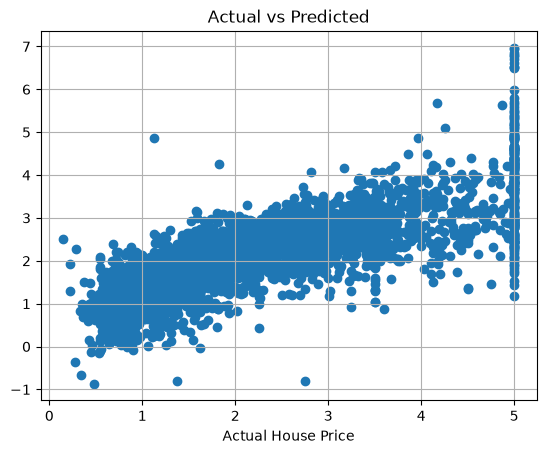

In [55]:
plt.Figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual House Price")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

Task

In [ ]:
#data:


## Experience                        Education             skills       salary
#  1                                  12                    2           25000
#  2                                  12                    3           30000
#  3                                  15                    4           38000
#  4                                  16                    5           47000
#  5                                  18                    6           60000
#  6                                  18                    7           70000

In [57]:
data={
    'Experience':[1,2,3,4,5,6],
    'Education':[12,12,15,16,18,18],
    'skills':[2,3,4,5,6,7],
    'salary': [25000,30000,38000,47000,60000,70000]

}
df= pd.DataFrame(data)
print(df)

   Experience  Education  skills  salary
0           1         12       2   25000
1           2         12       3   30000
2           3         15       4   38000
3           4         16       5   47000
4           5         18       6   60000
5           6         18       7   70000


In [58]:
x=df[['Experience','Education','skills']]
y=df['salary']

In [60]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [61]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[4821.43,1142.86,4821.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Experience','Education','skills']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.361e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [62]:
print(model.intercept_)

-13607.142857142855


In [63]:
y_pred = model.predict(x_test)

In [65]:
comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted": y_pred
})
comparison.head(20)

,Actual,Predicted
0,25000,14571.428571
1,30000,24214.285714


In [66]:
predicted_salary=model.predict([[7,19,8]])
print(predicted_salary)

[80428.57142857]


c:\Users\Shaur\OneDrive\Desktop\AI IBM Virtual Internship\PBEL12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
print(df.columns)

Index(['Experience', 'Education', 'skills', 'salary'], dtype='str')


In [85]:
new_salary= [[
    8,20,6
]]# Data frame mein convert karne ke liye
prediction_new_salary= model.predict(new_salary)
prediction_new_salary[0]

c:\Users\Shaur\OneDrive\Desktop\AI IBM Virtual Internship\PBEL12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(76749.99999999999)

In [96]:
df.describe()

,Experience,Education,skills,salary
count,6.000000,6.000000,6.000000,6.000000
mean,3.500000,15.166667,4.500000,45000.000000
std,1.870829,2.714160,1.870829,17481.418707
min,1.000000,12.000000,2.000000,25000.000000
25%,2.250000,12.750000,3.250000,32000.000000
50%,3.500000,15.500000,4.500000,42500.000000
75%,4.750000,17.500000,5.750000,56750.000000
max,6.000000,18.000000,7.000000,70000.000000


In [91]:
df.isnull().sum()

Experience    0
Education     0
skills        0
salary        0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(0)

In [86]:
mae=mean_absolute_error(y_test,y_pred)# It tells the average mistake your model makes
mae

8107.142857142848

In [87]:
mse =mean_squared_error(y_test,y_pred)#errors more then penalty high
mse

71114795.9183672

In [88]:
r2=r2_score(y_test,y_pred)# Accurate result
r2

-10.378367346938752

In [89]:
residuals =y_test-y_pred
residuals

0    10428.571429
1     5785.714286
Name: salary, dtype: float64

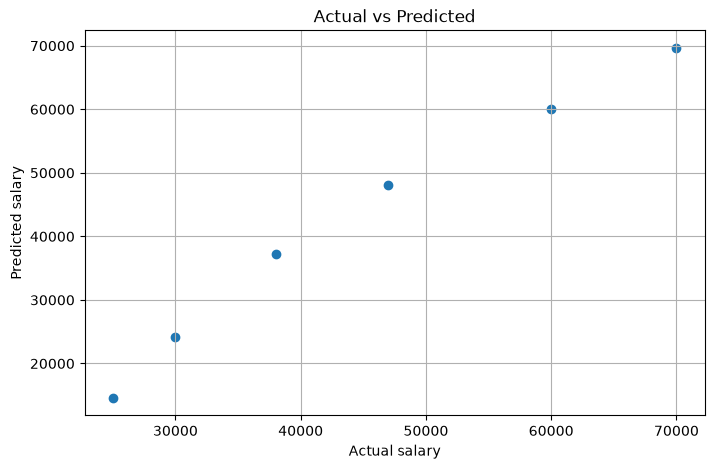

In [111]:
all_pred =model.predict(x)
plt.figure(figsize=(8,5))
plt.scatter(y,all_pred)
plt.xlabel("Actual salary")
plt.ylabel("Predicted salary")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

# HOW 

# mileage =[15, 18, 20, 22, 25, 28]
# engine (cc) =[1000, 1200, 1500, 1800, 2000, 2200]
# age =[2, 3, 5, 4, 6, 7]
# price= [5L, 6L, 7.5L, 9L, 11L, 13L]

# Dataframe -> split -> MLR
# m-24, en- 1800, age- 5
# mae, mse, r2score graph actual vs predict

In [10]:
data={
    'mileage': [15, 18, 20, 22, 25, 28],
    'engine(cc)': [1000, 1200, 1500, 1800, 2000, 2200],
    'age': [2, 3, 5, 4, 6, 7],
    'price': [5, 6, 7.5, 9, 11, 13]
}
df= pd.DataFrame(data)
print(df)

   mileage  engine(cc)  age  price
0       15        1000    2    5.0
1       18        1200    3    6.0
2       20        1500    5    7.5
3       22        1800    4    9.0
4       25        2000    6   11.0
5       28        2200    7   13.0


In [11]:
x=df[['mileage','engine(cc)','age']]
y=df['price']

In [12]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=40
)

In [27]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 1.4 ,-0.01,-0.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['mileage','engine(cc)','age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [28]:
print(model.intercept_)

-8.999999999998657


In [26]:
y_pred = model.predict(x_test)
print(y_pred)

[13.5  7.5]


In [23]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted": y_pred
})
print(comparison)

   Actual  Predicted
5    13.0       13.5
1     6.0        7.5


In [17]:
mae= mean_absolute_error(y_test,y_pred)
mae

0.999999999999897

In [18]:
mse= mean_squared_error(y_test,y_pred)
mse

1.2500000000002238

In [19]:
r2=r2_score(y_test,y_pred)# Accurate result
r2

0.8979591836734511

In [20]:
df.isnull().sum()

mileage       0
engine(cc)    0
age           0
price         0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
new_price= [[
    24,1800,5
]]# Data frame mein convert karne ke liye
prediction_new_price= model.predict(new_price)
prediction_new_price[0]

c:\Users\Shaur\OneDrive\Desktop\AI IBM Virtual Internship\PBEL12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(11.299999999999812)

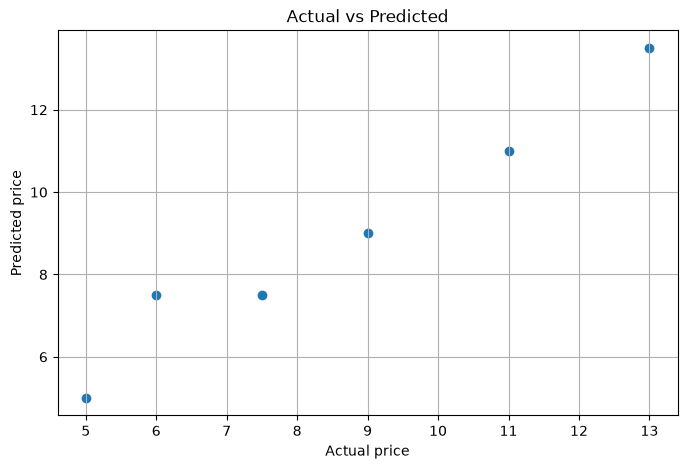

In [25]:
all_pred =model.predict(x)
plt.figure(figsize=(8,5))
plt.scatter(y,all_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()